<a href="https://colab.research.google.com/github/pmanideep20/Machine-Learning/blob/main/JOB_MARKET_TREND_ANALYZER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Job Market Trend Analyzer**

## **Load Data**

In [2]:
!pip install kaggle


In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"manideepchowdary20","key":"8001d2122b8f55018a4d22b1be40e2f0"}'}

In [4]:
!mkdir ~/.kaggle

In [5]:
!cp kaggle.json ~/.kaggle/

In [8]:
ls-ltr ~/.kaggle/

total 4
-rw------- 1 root root 74 Jul 27 10:07 kaggle.json


In [7]:
!chmod 600 ~/.kaggle/kaggle.json

In [9]:
!kaggle datasets list


ref                                                                   title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset        FIFA World Cup 2026 Player Performance Dataset        4154062  2026-06-10 12:58:47.093000          19437        481                1  
harshadapatil31/student-performance-and-study-habits-dataset          Student Performance & Study Habits Dataset              15035  2026-07-06 06:28:52.743000           2712         50                1  
abbas829/ecommerce-sales-dataset                                      Ecommerce sales dataset                                110951  2026-07-03 00:59:03.347000           5119      

In [10]:
!kaggle datasets list -s 'ai_job_dataset.csv'

ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
bismasajjad/global-ai-job-market-and-salary-trends-2025          Global AI Job Market & Salary Trends 2025              1130756  2025-06-29 08:16:54.867000          31023        339                1  
pratyushpuri/global-ai-job-market-trend-2025                     Global AI Job Market Trends & Salary Insights 2025      529004  2025-06-29 16:35:50.887000           2290         33                1  
alihassankamal/global-ai-adoption-and-trends-dataset-2024-2025   Global AI Adoption & Trends Dataset (2024-2025)        1130756  2026-01-31 13:59:19.457000            419         36       0.235294

In [11]:
!kaggle datasets download -d 'bismasajjad/global-ai-job-market-and-salary-trends-2025' -p ../data/KaggleDatasetsforaijobdata

Dataset URL: https://www.kaggle.com/datasets/bismasajjad/global-ai-job-market-and-salary-trends-2025
License(s): CC0-1.0
100% 1.08M/1.08M [00:00<00:00, 135MB/s]



In [15]:
ls-ltr ../data/KaggleDatasetsforaijobdata

total 6272
-rwxrwxrwx 1 root root 2591213 Jun 29  2025 ai_job_dataset.csv*
-rw-r--r-- 1 root root 1130756 Jun 29  2025 global-ai-job-market-and-salary-trends-2025.zip
-rw-r--r-- 1 root root 2692867 Jun 29  2025 ai_job_dataset1.csv


In [13]:
!unzip ../data/KaggleDatasetsforaijobdata/global-ai-job-market-and-salary-trends-2025.zip -d ../data/KaggleDatasetsforaijobdata

Archive:  ../data/KaggleDatasetsforaijobdata/global-ai-job-market-and-salary-trends-2025.zip
  inflating: ../data/KaggleDatasetsforaijobdata/ai_job_dataset.csv  
  inflating: ../data/KaggleDatasetsforaijobdata/ai_job_dataset1.csv  


In [14]:
!chmod 777 ../data/KaggleDatasetsforaijobdata/ai_job_dataset.csv

In [16]:
import pandas as pd
df = pd.read_csv('../data/KaggleDatasetsforaijobdata/ai_job_dataset.csv')
df

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics


## **Analysis**

In [17]:
title = df['job_title'].value_counts().head(20)
title

,count
job_title,
Machine Learning Researcher,808
AI Software Engineer,784
Autonomous Systems Engineer,777
Machine Learning Engineer,772
AI Architect,771
Head of AI,765
NLP Engineer,762
Robotics Engineer,759
Data Analyst,759


In [18]:
df['company_name'].value_counts().head(20)


,count
company_name,
TechCorp Inc,980
Cognitive Computing,972
AI Innovations,964
Digital Transformation LLC,961
Quantum Computing Inc,960
Future Systems,960
Cloud AI Solutions,951
Predictive Systems,947
Smart Analytics,927


In [19]:
location = df['company_location'].value_counts().head(20)
location


,count
company_location,
Germany,814
Denmark,778
Canada,769
France,769
Austria,765
Singapore,764
China,763
India,754
Sweden,752


### **Visualization**

In [20]:
skills_input = input("Enter the skills you are looking for (comma-separated): ")
skills = [skill.strip().lower() for skill in skills_input.split(',')]
print(f"You entered: {skills}")

Enter the skills you are looking for (comma-separated): python,aws,tableau,nlp,java,sql,tensorflow
You entered: ['python', 'aws', 'tableau', 'nlp', 'java', 'sql', 'tensorflow']


In [21]:
from collections import Counter

counter = Counter()

for desc in df['required_skills']:
    text = str(desc).lower()

    for skill in skills:
        if skill in text:
            counter[skill] += 1

print(counter)

Counter({'python': 4450, 'sql': 3407, 'tensorflow': 3022, 'java': 2578, 'tableau': 2341, 'nlp': 2145, 'aws': 2018})


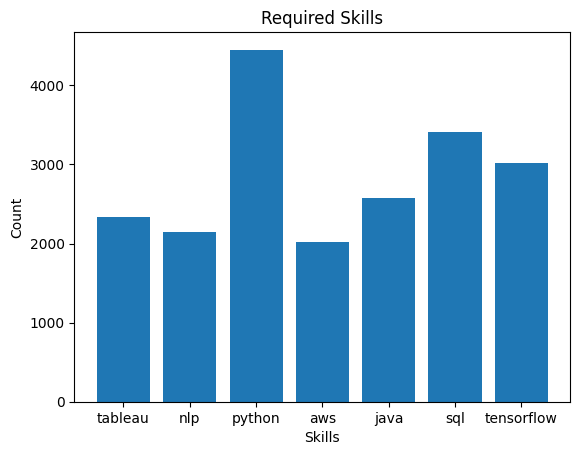

In [22]:
import matplotlib.pyplot as plt

plt.bar(counter.keys(), counter.values())
plt.xlabel('Skills')
plt.ylabel('Count')
plt.title('Required Skills')
plt.show()

In [23]:
x= df['job_title']
y= df['company_location']

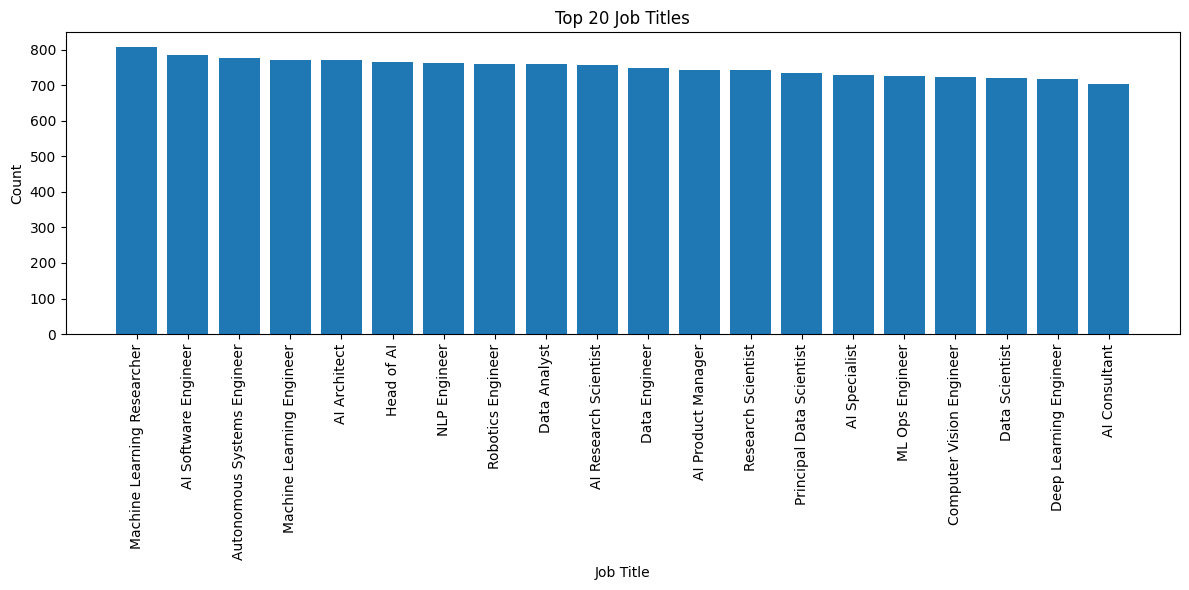

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(title.index, title.values)
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.title('Top 20 Job Titles')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

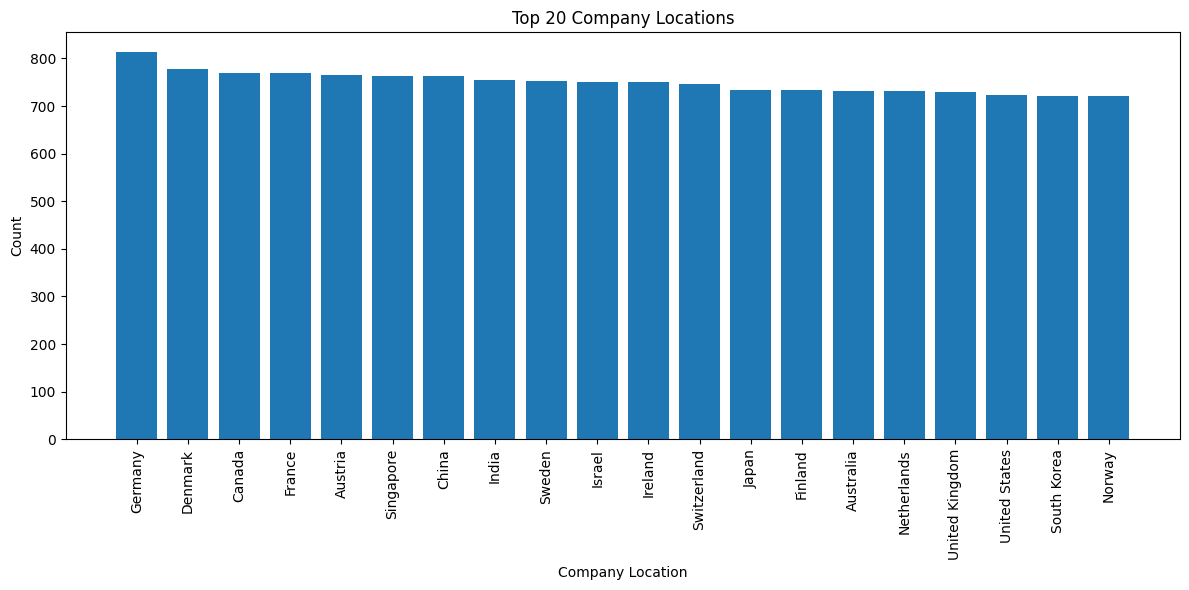

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(location.index, location.values)
plt.xlabel('Company Location')
plt.ylabel('Count')
plt.title('Top 20 Company Locations')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## **Prediction**

In [26]:
a = df['job_title']
b = df['salary_usd']

In [27]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Convert 'job_title' to numerical using one-hot encoding
a_encoded = pd.get_dummies(a, prefix='job_title')

rf = RandomForestClassifier(max_depth=2, random_state=0)
rf.fit(a_encoded, b)

RandomForestClassifier(max_depth=2, random_state=0)

In [28]:
a_rf_pred = rf.predict(a_encoded)
a_rf_pred

array([ 54645, 127730, 114754, ...,  81533,  69641,  67383])

In [29]:
req_job = input("Enter the job title: ")


Enter the job title: AI Architect


In [30]:
new_job_title = pd.Series([req_job])

new_job_title_encoded = pd.get_dummies(new_job_title, prefix='job_title')

missing_cols = set(a_encoded.columns) - set(new_job_title_encoded.columns)
for c in missing_cols:
    new_job_title_encoded[c] = False

new_job_title_encoded = new_job_title_encoded[a_encoded.columns]

In [31]:
predicted_salary = rf.predict(new_job_title_encoded)

print(f"Predicted salary for {req_job}: {predicted_salary[0]:.2f} USD")

Predicted salary for AI Architect: 103311.00 USD


# **PROJECT OVERVIEW**

## Developed a comprehensive AI Job Market Trend Analyser to explore and predict salary trends. The project involved:

**Data Acquisition:** Utilized the Kaggle API to download and preprocess a dataset containing global AI job market and salary trends.
Exploratory Data Analysis (EDA): Analyzed key features such as top job titles, company locations, and extracted frequently required skills (e.g., Python, SQL, TensorFlow, NLP) to understand demand and distribution.

**Data Visualization:** Generated insightful visualizations, including bar charts for job title frequency, company location distribution, and skill requirements, to highlight market patterns.

**Predictive Modeling:** Implemented a Random Forest Classifier to predict salary_usd based on job_title, demonstrating the ability to estimate potential earnings for various AI roles. The model was trained and evaluated to provide salary predictions for user-specified job titles.